[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wesmail/probabilistic-forecasting/blob/main/01-point-vs-probabilistic/post1_point_vs_probabilistic.ipynb)

# A Practical Guide to Point vs. Probabilistic Forecasting

**Companion notebook to:** *"Your Model's MSE Is Lying to You"*

This notebook trains **two transformers with an identical backbone** on the same synthetic physical signal. The only difference between them is the training objective:

- **Model A** is trained with plain **MSE** and outputs a single number per step.
- **Model B** is trained with the **Gaussian negative log-likelihood (NLL)** and outputs a mean $\mu$ *and* a standard deviation $\sigma$ per step.

Both models will end up with very similar test-set MSE. What they do *not* have in common is whether you can trust them to tell you when they're unsure — which turns out to matter a lot once you use a forecast to make a decision.

Runtime: a couple of minutes on CPU. No GPU needed.

## 1. A synthetic signal with *heteroscedastic* noise

We build a toy signal that behaves like a real physical time series:

$$x(t) = \underbrace{A_1 \sin(2\pi t / P_1) + A_2 \sin(2\pi t / P_2 + \phi)}_{\text{signal}(t)} + \varepsilon(t), \qquad \varepsilon(t) \sim \mathcal{N}(0, \sigma(t)^2)$$

The signal itself is just two superposed oscillations, think of it as a stand-in for any real physical background with a slow mode and a faster resonance.

The important part is $\sigma(t)$: the noise **standard deviation itself oscillates**, on its *own* period, independent of the signal's periods. This mimics something very real in seismic / environmental data: a noise floor that is modulated by something external (e.g. day/night human activity) and has nothing to do with the physical process you're trying to measure.

This is exactly the situation where a single point prediction is dangerous: the *right answer* stays similarly hard to pin down in absolute terms, but the *right amount of uncertainty to report* changes a lot depending on where you are in the cycle.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.stats import norm

torch.manual_seed(0)   # reproducibility: same weights every run
np_rng = np.random.default_rng(0)   # reproducibility: same noise every run


def generate_series(n_steps=3000, dt=1.0,
                     A1=1.0, P1=200.0,        # slow "physical" oscillation
                     A2=0.4, P2=37.0,         # faster resonance
                     sigma_min=0.05, sigma_max=0.45, P_noise=130.0,  # noise envelope
                     seed=0):
    """Generate x(t) = signal(t) + noise(t), where noise(t) has its own
    oscillating standard deviation sigma(t), independent of the signal's periods."""
    rng = np.random.default_rng(seed)
    t = np.arange(n_steps) * dt

    signal = A1 * np.sin(2 * np.pi * t / P1) + A2 * np.sin(2 * np.pi * t / P2 + 0.7)

    # sigma(t) oscillates smoothly between sigma_min ("quiet") and sigma_max ("noisy")
    sigma_t = sigma_min + (sigma_max - sigma_min) * 0.5 * (1 + np.sin(2 * np.pi * t / P_noise - np.pi / 2))

    eps = rng.normal(0.0, sigma_t)   # heteroscedastic noise: different sigma at every t
    x = signal + eps
    return t, x, signal, sigma_t


t, x, signal, sigma_t = generate_series()
print(f"generated {len(x)} steps  |  sigma(t) ranges from {sigma_t.min():.2f} to {sigma_t.max():.2f}")

generated 3000 steps  |  sigma(t) ranges from 0.05 to 0.45


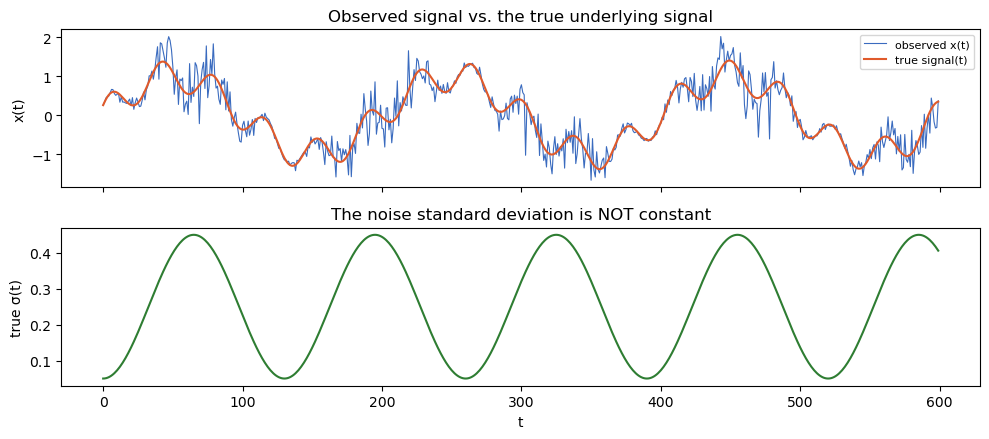

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(10, 4.5), sharex=True)

axes[0].plot(t[:600], x[:600], lw=0.8, color="#3a6bbf", label="observed x(t)")
axes[0].plot(t[:600], signal[:600], lw=1.5, color="#e05a2b", label="true signal(t)")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_ylabel("x(t)")
axes[0].set_title("Observed signal vs. the true underlying signal")

axes[1].plot(t[:600], sigma_t[:600], color="#2e7d32")
axes[1].set_ylabel("true σ(t)")
axes[1].set_xlabel("t")
axes[1].set_title("The noise standard deviation is NOT constant")

plt.tight_layout()
plt.show()

Notice the noise band visibly tightens and loosens on its own rhythm, that's the thing a point forecast has no way of expressing.

## 2. From a raw series to supervised windows

Following the same setup as the post: we observe a **context window** of length $T$ = 20 steps and predict a single value $H$ = 1 step ahead. (Multi-step rollout is the subject of the *next* post, here we're only training the one-step predictive distribution.)

In [3]:
CONTEXT = 20  # T: how many past steps the model sees

def make_windows(series, context_len):
    """Slice the series into (context, target) pairs for supervised training."""
    X, y, sig_at_target = [], [], []
    for i in range(len(series) - context_len):
        X.append(series[i:i + context_len])          # T past values
        y.append(series[i + context_len])             # the next value (H=1)
        sig_at_target.append(sigma_t[i + context_len])  # true sigma at that point (for evaluation only)
    return (np.array(X, dtype=np.float32),
            np.array(y, dtype=np.float32),
            np.array(sig_at_target, dtype=np.float32))

X, y, sig_target = make_windows(x, CONTEXT)

# temporal split: train on the first 70%, test on the later 30% -- never shuffle
# time series data across the train/test boundary
n_total = len(X)
n_train = int(0.7 * n_total)
X_train, y_train = X[:n_train], y[:n_train]
X_test, y_test, sig_test = X[n_train:], y[n_train:], sig_target[n_train:]

X_train_t, y_train_t = torch.from_numpy(X_train), torch.from_numpy(y_train)
X_test_t, y_test_t = torch.from_numpy(X_test), torch.from_numpy(y_test)

print(f"train windows: {n_train}   test windows: {n_total - n_train}")

train windows: 2086   test windows: 894


## 3. Two forecasters, one backbone

Both models below use the *exact same* transformer backbone: a linear embedding of each scalar observation, a learned positional embedding, and two self-attention encoder layers. The only difference is the head bolted on at the end:

- `mode="point"` → one linear output (a single number)
- `mode="gaussian"` → two linear outputs, $(\mu, \log\sigma)$

We predict $\log\sigma$ rather than $\sigma$ directly (so it can be negative, i.e. $\sigma$ automatically stays positive), and we **clamp** it, the same trick used in the lecture, so that a single bad batch early in training can't send $\sigma$ collapsing to zero or exploding to infinity.

In [4]:
class ForecastTransformer(nn.Module):
    def __init__(self, context_len, d_model=32, nhead=4, num_layers=2, mode="point"):
        super().__init__()
        assert mode in ("point", "gaussian")
        self.mode = mode

        self.input_proj = nn.Linear(1, d_model)     # embed each scalar observation
        self.pos_embed = nn.Parameter(torch.zeros(1, context_len, d_model))
        nn.init.normal_(self.pos_embed, std=0.02)     # learned position embedding

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=4 * d_model,
            batch_first=True, activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        out_dim = 1 if mode == "point" else 2   # point -> 1 number, gaussian -> (mu, log_sigma)
        self.head = nn.Linear(d_model, out_dim)

    def forward(self, x):
        # x: (batch, context_len) raw scalar observations
        h = self.input_proj(x.unsqueeze(-1)) + self.pos_embed   # (B, T, d_model)
        h = self.encoder(h)                                      # (B, T, d_model)
        h_last = h[:, -1, :]                                     # summarize context in the last position
        out = self.head(h_last)                                  # (B, out_dim)

        if self.mode == "point":
            return out.squeeze(-1)                                # (B,)
        else:
            mu, log_sigma = out[:, 0], out[:, 1]
            log_sigma = torch.clamp(log_sigma, min=-5.0, max=2.0)  # keep sigma in a sane range
            return mu, log_sigma


def gaussian_nll(mu, log_sigma, target):
    """Negative log-likelihood of `target` under N(mu, exp(log_sigma)^2).
    Two terms in tension: the fit term wants sigma -> 0 (fit tightly), the
    log_sigma term punishes overconfidence (being tight AND wrong is costly)."""
    sigma = torch.exp(log_sigma)
    return (log_sigma + 0.5 * ((target - mu) / sigma) ** 2).mean()

## 4. Training both models

Same optimizer, same number of epochs, same batch size, the only thing that changes between the two training runs below is the loss function each model is optimizing.

In [5]:
def train(model, loss_fn, epochs=150, lr=1e-3, batch_size=64):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    n = X_train_t.shape[0]
    for epoch in range(epochs):
        perm = torch.randperm(n)
        total_loss = 0.0
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            xb, yb = X_train_t[idx], y_train_t[idx]
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
            total_loss += loss.item() * len(idx)
        if (epoch + 1) % 30 == 0:
            print(f"  epoch {epoch+1:3d}   loss {total_loss/n:.4f}")
    return model

point_loss = lambda out, yb: nn.functional.mse_loss(out, yb)
prob_loss = lambda out, yb: gaussian_nll(out[0], out[1], yb)

print("Training point model (MSE)...")
point_model = ForecastTransformer(CONTEXT, mode="point")
train(point_model, point_loss)

print("\nTraining probabilistic model (Gaussian NLL)...")
prob_model = ForecastTransformer(CONTEXT, mode="gaussian")
train(prob_model, prob_loss)

Training point model (MSE)...
  epoch  30   loss 0.1085
  epoch  60   loss 0.1069
  epoch  90   loss 0.0939
  epoch 120   loss 0.0849
  epoch 150   loss 0.0771

Training probabilistic model (Gaussian NLL)...
  epoch  30   loss -0.7401
  epoch  60   loss -0.7810
  epoch  90   loss -0.8444
  epoch 120   loss -0.8873
  epoch 150   loss -0.9159


ForecastTransformer(
  (input_proj): Linear(in_features=1, out_features=32, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (head): Linear(in_features=32, out_features=2, bias=True)
)

## 5. Same accuracy? Compare test-set MSE

This is the first half of the punchline: judged purely on point accuracy, the two models
should look nearly indistinguishable.

In [6]:
point_model.eval()
prob_model.eval()
with torch.no_grad():
    point_pred = point_model(X_test_t).numpy()
    mu_pred, log_sigma_pred = prob_model(X_test_t)
    mu_pred = mu_pred.numpy()
    sigma_pred = torch.exp(log_sigma_pred).numpy()

mse_point = np.mean((point_pred - y_test) ** 2)
mse_prob = np.mean((mu_pred - y_test) ** 2)
print(f"Test MSE -- point model:          {mse_point:.4f}")
print(f"Test MSE -- probabilistic model:  {mse_prob:.4f}   (mu only)")

# The only "uncertainty" a point model can offer after the fact: one global
# residual std computed over the training set. This is what people reach for
# when they bolt a confidence interval onto a point-prediction model.
resid_std_train = np.std(y_train - point_model(X_train_t).detach().numpy())
print(f"\nPoint model's single global residual std (used as a fixed band below): {resid_std_train:.4f}")

Test MSE -- point model:          0.1211
Test MSE -- probabilistic model:  0.1154   (mu only)

Point model's single global residual std (used as a fixed band below): 0.2537


As expected: the two models are nearly tied on MSE. If you stopped the evaluation here, you'd conclude they're interchangeable.

## 6. The real test: calibration by regime

Split the test set into a **quiet** half (true $\sigma(t)$ below the median) and a **noisy** half (above the median), and check: does a nominal 90% interval actually contain the true value about 90% of the time, *in each regime separately*?

- The **probabilistic model** gets an adaptive band: $\mu \pm z_{0.90}\, \sigma(t)$, using its own per-step $\sigma$.
- The **point model** only has one number to offer for uncertainty, the fixed global residual std from training, so its band is the same width everywhere, regardless of which regime you're actually in.

In [7]:
z90 = norm.ppf(0.95)   # for a 90% central interval

quiet_mask = sig_test < np.median(sig_test)
noisy_mask = ~quiet_mask

def coverage(lower, upper, y_true):
    return np.mean((y_true >= lower) & (y_true <= upper))

# probabilistic model: band width adapts to the model's own sigma at each point
prob_lower, prob_upper = mu_pred - z90 * sigma_pred, mu_pred + z90 * sigma_pred
cov_prob_quiet = coverage(prob_lower[quiet_mask], prob_upper[quiet_mask], y_test[quiet_mask])
cov_prob_noisy = coverage(prob_lower[noisy_mask], prob_upper[noisy_mask], y_test[noisy_mask])

# point model: only a single, constant-width band is available
point_lower, point_upper = point_pred - z90 * resid_std_train, point_pred + z90 * resid_std_train
cov_point_quiet = coverage(point_lower[quiet_mask], point_upper[quiet_mask], y_test[quiet_mask])
cov_point_noisy = coverage(point_lower[noisy_mask], point_upper[noisy_mask], y_test[noisy_mask])

print("Nominal target: 90% coverage in BOTH regimes\n")
print(f"{'':28s} {'quiet regime':>14s} {'noisy regime':>14s}")
print(f"{'probabilistic model':28s} {cov_prob_quiet*100:>13.1f}% {cov_prob_noisy*100:>13.1f}%")
print(f"{'point model (fixed band)':28s} {cov_point_quiet*100:>13.1f}% {cov_point_noisy*100:>13.1f}%")

Nominal target: 90% coverage in BOTH regimes

                               quiet regime   noisy regime
probabilistic model                   87.7%          83.3%
point model (fixed band)              95.0%          63.1%


This is the whole argument in one table. The **probabilistic model** lands close to **90%** in *both* regimes, its band genuinely tracks how much to trust each prediction. The **point model**, forced to use one fixed band width everywhere, over-covers in the quiet regime (wasting precision, the band is wider than it needs to be) and badly **under-covers in the noisy regime**, exactly where you most need to know the model is unsure, it's silently overconfident.

Same MSE. Very different reliability.

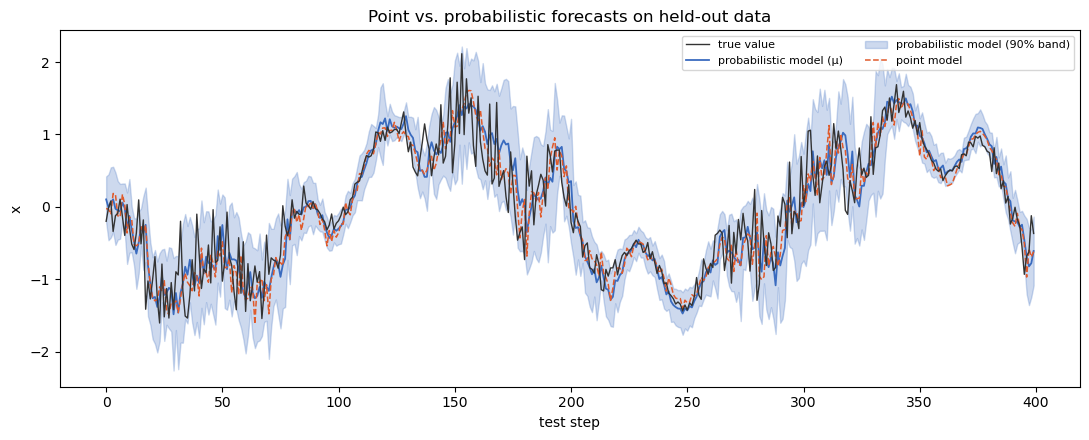

In [8]:
t_test = np.arange(len(y_test))
window = slice(0, 400)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(t_test[window], y_test[window], color="#333", lw=1.0, label="true value", zorder=3)
ax.plot(t_test[window], mu_pred[window], color="#3a6bbf", lw=1.3, label="probabilistic model (μ)")
ax.fill_between(t_test[window], prob_lower[window], prob_upper[window],
                 color="#3a6bbf", alpha=0.25, label="probabilistic model (90% band)")
ax.plot(t_test[window], point_pred[window], color="#e05a2b", lw=1.1, ls="--", label="point model")
ax.set_xlabel("test step")
ax.set_ylabel("x")
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.set_title("Point vs. probabilistic forecasts on held-out data")
plt.tight_layout()
plt.show()

Watch the shaded band: it visibly widens and narrows as the true noise envelope cycles through noisy and quiet stretches, the model learned that from data, it was never told where the regimes were.

## 7. Why this matters for a decision

Suppose you only care whether $x$ is about to exceed some threshold. A point model can only say yes/no. A probabilistic model can give you an actual probability of exceeding it, which is what you'd actually want to feed into a decision.

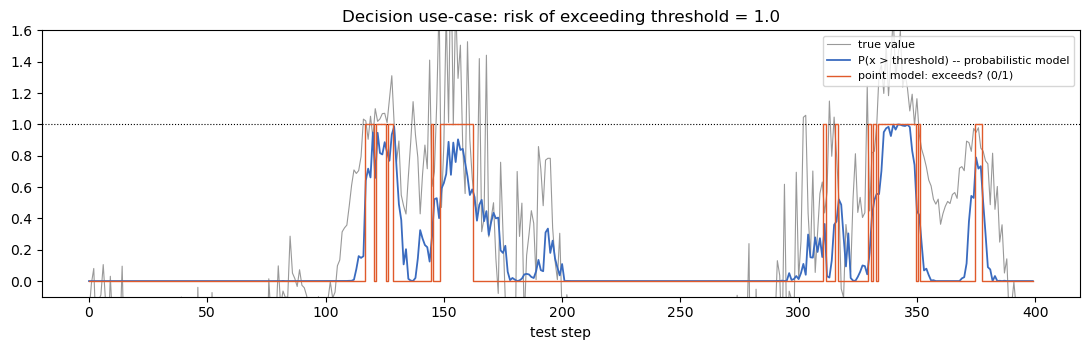

In [9]:
threshold = 1.0
p_exceed = 1 - norm.cdf(threshold, loc=mu_pred, scale=sigma_pred)   # P(x > threshold) from the Gaussian model
point_flag = (point_pred > threshold).astype(float)                 # all the point model can tell you

fig2, ax2 = plt.subplots(figsize=(11, 3.6))
ax2.plot(t_test[window], y_test[window], color="#999", lw=0.8, label="true value")
ax2.axhline(threshold, color="black", lw=0.8, ls=":")
ax2.plot(t_test[window], p_exceed[window], color="#3a6bbf", lw=1.3, label="P(x > threshold) -- probabilistic model")
ax2.step(t_test[window], point_flag[window], color="#e05a2b", lw=1.0, where="mid", label="point model: exceeds? (0/1)")
ax2.set_ylim(-0.1, 1.6)
ax2.set_xlabel("test step")
ax2.legend(loc="upper right", fontsize=8)
ax2.set_title(f"Decision use-case: risk of exceeding threshold = {threshold}")
plt.tight_layout()
plt.show()

## Summary

- Same backbone, same training budget, two loss functions.
- Nearly identical point accuracy (MSE).
- Wildly different reliability once you check calibration **by regime** rather than on average, the point model's fixed band is right on average and wrong exactly where it matters.

**Next up:** this notebook only ever predicted one step ahead. The follow-up post covers what happens when you roll a probabilistic model forward multiple steps stochastic rollout, Monte Carlo trajectories, and how to check whether the resulting multi-step bands are actually calibrated (coverage plots, PIT histograms).